In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [49]:
# Load datasets

fund_master = pd.read_csv("../data/processed/clean_fund_master.csv")

nav_history = pd.read_csv("../data/processed/clean_nav_history.csv")

aum_by_fund_house = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")

monthly_sip_inflows = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")

category_inflows = pd.read_csv("../data/processed/clean_category_inflows.csv")

industry_folio_count = pd.read_csv("../data/processed/clean_industry_folio_count.csv")

scheme_performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

portfolio_holdings = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

investor_transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")

benchmark_indices = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


# Compute Daily Returns

In [50]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


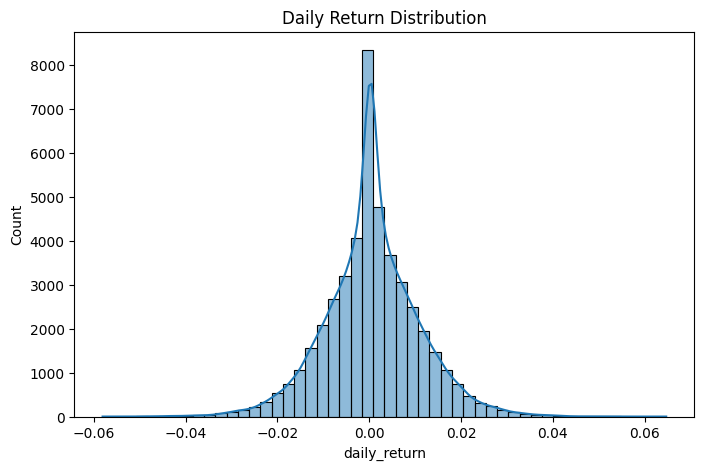

In [51]:
# Validate returns
plt.figure(figsize=(8,5))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

# CAGR Calculation

In [52]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_history = nav_history.sort_values(
    ["amfi_code","date"]
)

In [53]:
def calculate_cagr(data, years):

    data = data.sort_values("date")

    end_date = data["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    period_data = data[
        data["date"] >= start_date
    ]

    # Not enough data
    if len(period_data) == 0:
        return None


    start_nav = period_data.iloc[0]["nav"]

    end_nav = period_data.iloc[-1]["nav"]


    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1


    return cagr

In [54]:
cagr_table = []


for fund, group in nav_history.groupby("amfi_code"):

    cagr_table.append({

        "amfi_code": fund,

        "CAGR_1Y": calculate_cagr(group,1),

        "CAGR_3Y": calculate_cagr(group,3),

        "CAGR_5Y": calculate_cagr(group,5)

    })


cagr_df = pd.DataFrame(cagr_table)


cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


# Sharpe Ratio

In [55]:
rf_daily = 0.065/252

def sharpe_ratio(returns):

    excess_return = returns - rf_daily

    return (
        excess_return.mean()
        /
        returns.std()
    )*np.sqrt(252)


sharpe=[]

for fund,group in nav_history.groupby("amfi_code"):

    sharpe.append({

        "amfi_code":fund,

        "Sharpe":
        sharpe_ratio(
            group["daily_return"].dropna()
        )

    })


sharpe_df=pd.DataFrame(sharpe)

In [56]:
sharpe_df

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661
5,101208,-0.815567
6,102885,0.817099
7,102886,-0.205832
8,102887,0.619518
9,118632,1.081659


# Maximum Drawdown

In [57]:
# Function
def max_drawdown(nav_values):

    running_max = nav_values.cummax()

    drawdown = (
        nav_values/running_max
    )-1


    return drawdown.min()

In [58]:
# Calculation
drawdown=[]


for fund,group in nav_history.groupby("amfi_code"):

    drawdown.append({

        "amfi_code":fund,

        "Max_Drawdown":
        max_drawdown(
            group["nav"]
        )

    })


dd_df=pd.DataFrame(drawdown)

In [59]:
dd_df

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469
5,101208,-0.001622
6,102885,-0.108599
7,102886,-0.280011
8,102887,-0.215398
9,118632,-0.174141


# alpha and beta 

In [60]:
# Change datatype of date column
benchmark_indices['date'] = pd.to_datetime(benchmark_indices['date'])
benchmark_indices.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[us]
 1   index_name   8050 non-null   str           
 2   close_value  8050 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 188.8 KB


In [61]:
# calculate fund return
nav = nav_history.sort_values(
    ["amfi_code","date"]
)


nav["fund_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [62]:
# calculate benchmark return
benchmark = benchmark_indices.sort_values(
    "date"
)


benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

In [63]:
alpha_beta = []

# Calculate Alpha and Beta for each fund
for fund_id, group in nav.groupby("amfi_code"):

    # Merge fund returns with benchmark returns by date
    merged = pd.merge(
        group[["date", "fund_return"]],
        benchmark[["date", "benchmark_return"]],
        on="date"
    )

    # Remove missing returns
    merged = merged.dropna()

    # Regression
    result = linregress(
        merged["benchmark_return"],
        merged["fund_return"]
    )

    alpha_beta.append({
        "amfi_code": fund_id,
        "Alpha": result.intercept * 252,   # Annualized Alpha
        "Beta": result.slope               # Beta
    })


# Convert to DataFrame
alpha_beta = pd.DataFrame(alpha_beta)

# Display result
alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037661,-0.000003
1,100025,0.044818,-0.000003
2,100033,0.265138,0.000012
3,101206,0.208464,0.000011
4,101207,0.109861,-0.000005


# Fund Scorecard (0–100) 

In [64]:
# Combine All Tables
scorecard = (
    cagr_df
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta,
        on="amfi_code"
    )
    .merge(
        dd_df,
        on="amfi_code"
    )
)

In [65]:
# CAGR Rank
scorecard["return_rank"] = (
    scorecard["CAGR_3Y"]
    .rank(pct=True)*100
)

In [66]:
# Sharpe Rank
scorecard["sharpe_rank"] = (
    scorecard["Sharpe"]
    .rank(pct=True)*100
)

In [67]:
# Alpha Rank
scorecard["alpha_rank"] = (
    scorecard["Alpha"]
    .rank(pct=True)*100
)

In [68]:
# Maximum Drawdown Rank
scorecard["dd_rank"] = (
    scorecard["Max_Drawdown"]
    .rank(pct=True)*100
)

In [69]:
# Final Score
scorecard["Fund_Score"] = (

    0.30 * scorecard["return_rank"]

    +

    0.25 * scorecard["sharpe_rank"]

    +

    0.20 * scorecard["alpha_rank"]

    +

    0.10 * scorecard["dd_rank"]

)

In [70]:
# Rank Funds
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

In [71]:
scorecard.to_csv(
    "../Reports/fund_scorecard.csv",
    index=False
)

# Benchmark Comparison Chart

In [72]:
# Select top 5 score
top5 = (
    scorecard
    .sort_values(
        "Fund_Score",
        ascending=False
    )
    .head(5)
)

In [73]:
# Get only fund IDs

top5_funds = top5["amfi_code"]

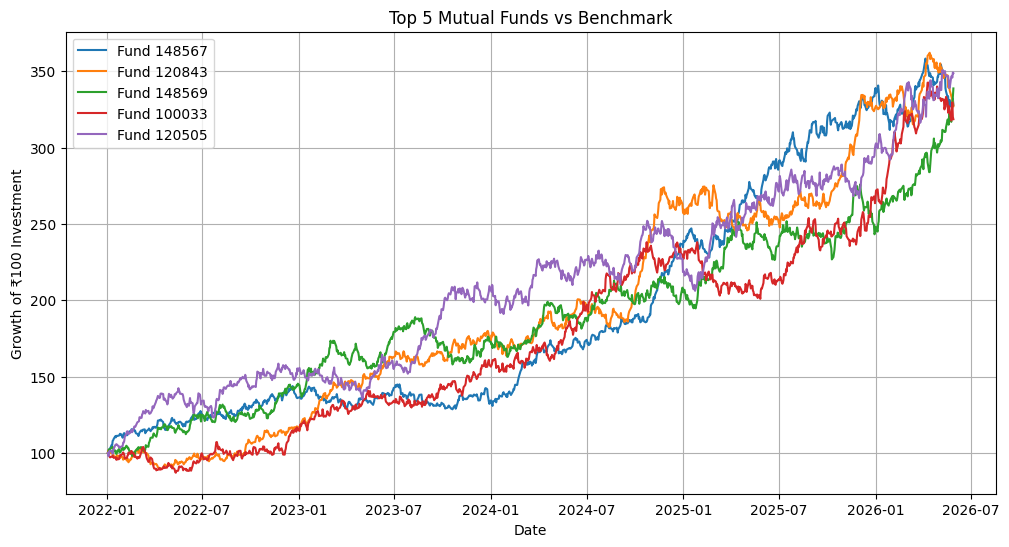

In [74]:
# Create Comparison Chart
plt.figure(figsize=(12,6))


for fund in top5_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()


    temp["normalized_nav"] = (
        temp["nav"]
        /
        temp["nav"].iloc[0]
    ) * 100


    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=f"Fund {fund}"
    )


plt.title(
    "Top 5 Mutual Funds vs Benchmark"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Growth of ₹100 Investment"
)


plt.legend()

plt.grid(True)

plt.show()

In [75]:
# Add benchmark line( Add Nifty 100)
benchmark["normalized_index"] = (
    benchmark["close_value"]
    /
    benchmark["close_value"].iloc[0]
) * 100

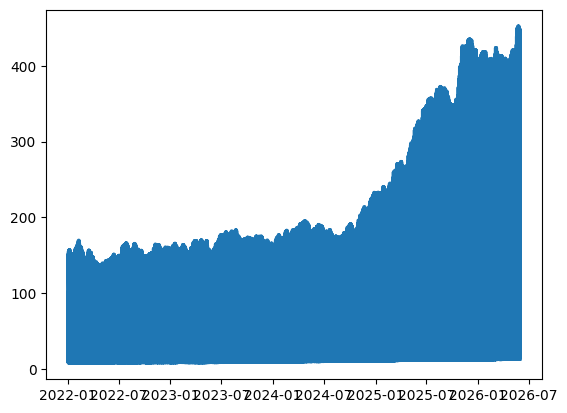

In [76]:
# Plot
plt.plot(
    benchmark["date"],
    benchmark["normalized_index"],
    label="Nifty 100",
    linewidth=3
)

In [77]:
# Calculate Tracking Error(Tracking Error=Std(Fund Return−Benchmark Return)×252)
tracking_error = (
    merged["fund_return"]
    -
    merged["benchmark_return"]
).std() * np.sqrt(252)

In [78]:
plt.savefig(
    "../Reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>